## 설치·인증·공통 함수



In [ ]:
%%capture
%pip install qiskit qiskit-ibm-runtime qiskit-aer pylatexenc

In [ ]:
%%capture
%pip install pennylane pennylane-qiskit qiskit-ibm-runtime qiskit-aer

import pennylane as qml
import matplotlib.pyplot as plt

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime.fake_provider import  FakeFez

from google.colab import userdata

# Colab Secrets에 IBM Quantum Platform API 토큰을 IBM_QUANTUM_TOKEN으로 저장해 두세요.
ibm_token = userdata.get('IBM_TOKEN')

SHOTS = 2048


def make_circuit(dev):
    """주어진 디바이스에서 실행할 Bell 상태 QNode를 생성.

    qiskit.remote는 analytic 모드를 지원하지 않으므로 반드시 shots가 필요합니다
    (shots는 디바이스 초기화 시 지정).
    """
    @qml.qnode(dev)
    def circuit():
        qml.Hadamard(wires=0)      # qubit-0에 H → 중첩
        qml.CNOT(wires=[0, 1])     # 0→1 CNOT → 얽힘
        return qml.counts()        # bitstring별 측정 횟수
    return circuit


def normalize_counts(counts):
    """counts 값을 파이썬 int로 통일."""
    return {k: int(v) for k, v in counts.items()}


def plot_counts(counts, title):
    """counts를 막대그래프로 시각화하고 각 막대 위에 숫자를 표기."""
    labels = sorted(counts)
    values = [counts[k] for k in labels]
    fig, ax = plt.subplots()
    bars = ax.bar(labels, values)
    ax.bar_label(bars, padding=2)      # 막대 위 숫자
    ax.set_xlabel("bitstring")
    ax.set_ylabel("counts")
    ax.set_title(title)
    ax.margins(y=0.1)                  # 상단 라벨 잘림 방지
    plt.show()

## IBM 시뮬레이터(fake backend, 기본값) 먼저 실행

/usr/local/lib/python3.12/dist-packages/pennylane/devices/device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


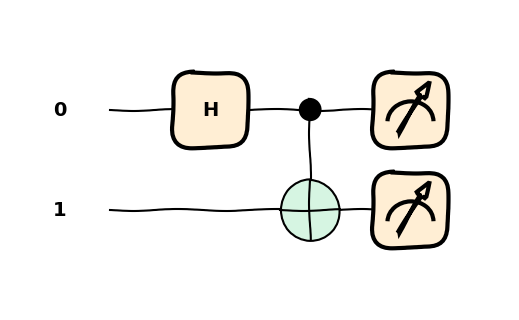

Fake simulator (fake_fez): {np.str_('00'): 1024, np.str_('01'): 10, np.str_('10'): 6, np.str_('11'): 1008}


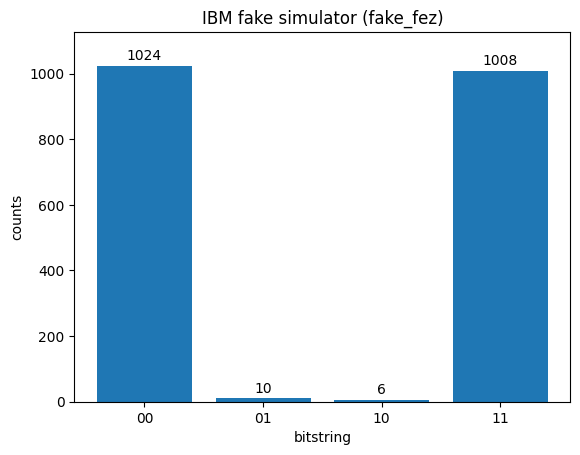

In [ ]:
# 기본 fake backend. 인증 없이 로컬에서 동작합니다.

fake_backend = FakeFez()   # ibm_fez(156큐빗 Heron r2)의 스냅샷 노이즈 모델


# qiskit.remote로 fake backend를 감싼 PennyLane 디바이스
sim_dev = qml.device("qiskit.remote", wires=2, backend=fake_backend, shots=SHOTS)
sim_circuit = make_circuit(sim_dev)

# 회로도 (실행 없음)
qml.draw_mpl(sim_circuit, style="sketch")()
plt.show()

# 시뮬레이터 실행 + 시각화 (이 셀만으로 완결)
sim_counts = normalize_counts(sim_circuit())
print(f"Fake simulator ({fake_backend.name}):", sim_counts)
plot_counts(sim_counts, f"IBM fake simulator ({fake_backend.name})")

## 실기 QPU 큐 상태 확인 및 가장 빈 backend 선택

In [ ]:
# ibm_quantum_platform이 기본 채널. 인스턴스 에러 시 instance="<CRN>" 추가.
service = QiskitRuntimeService(channel="ibm_quantum_platform", token=ibm_token)


def show_and_pick_backend(service, min_qubits=2):
    """가동 중 실기 QPU들의 대기 job 수를 표로 출력하고, 가장 비어 있는 backend 반환."""
    backends = service.backends(
        operational=True, simulator=False, min_num_qubits=min_qubits,
    )
    if not backends:
        raise RuntimeError("사용 가능한 실기 backend가 없습니다.")

    print(f"{'backend':22} {'qubits':>7} {'pending_jobs':>13} {'operational':>12}")
    print("-" * 58)
    rows = []
    for b in backends:
        st = b.status()
        rows.append((b, st.pending_jobs))
        print(f"{b.name:22} {b.num_qubits:>7} "
              f"{st.pending_jobs:>13} {str(st.operational):>12}")

    best = min(rows, key=lambda r: r[1])[0]   # pending_jobs 최소
    print(f"\n>>> 선택된 실기 QPU: {best.name} "
          f"(pending_jobs={best.status().pending_jobs}, {best.num_qubits} qubits)")
    return best


real_backend = show_and_pick_backend(service)
# 한 줄 대안: real_backend = service.least_busy(operational=True, simulator=False, min_num_qubits=2)

backend                 qubits  pending_jobs  operational
----------------------------------------------------------
ibm_fez                    156             5         True
ibm_marrakesh              156             1         True
ibm_kingston               156             3         True

>>> 선택된 실기 QPU: ibm_marrakesh (pending_jobs=1, 156 qubits)


## 실기 QPU 실행 및 시각화 (시뮬레이터 이후)

/usr/local/lib/python3.12/dist-packages/pennylane/devices/device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


Real QPU (ibm_marrakesh): {np.str_('00'): 1042, np.str_('01'): 12, np.str_('10'): 6, np.str_('11'): 988}


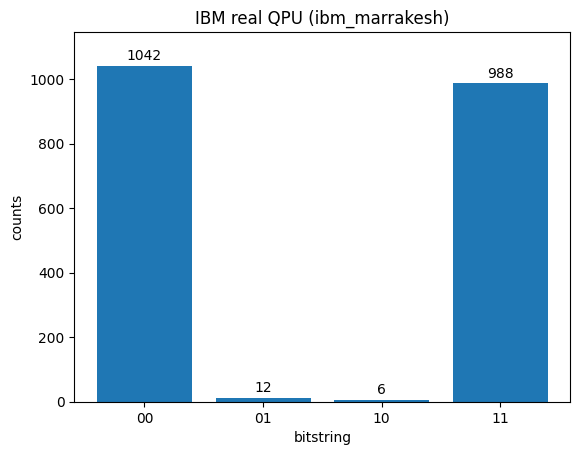

In [ ]:
# 선택된 실기 backend를 qiskit.remote로 감싼 PennyLane 디바이스
qpu_dev = qml.device("qiskit.remote", wires=2, backend=real_backend, shots=SHOTS)
qpu_circuit = make_circuit(qpu_dev)

# 주의: 실제 IBM QPU에 job 제출 → 큐 대기 + Open 플랜 사용 시간 소모
qpu_counts = normalize_counts(qpu_circuit())
print(f"Real QPU ({real_backend.name}):", qpu_counts)
plot_counts(qpu_counts, f"IBM real QPU ({real_backend.name})")

## 시뮬레이터 vs 실기 비교 (막대에 숫자 표기)

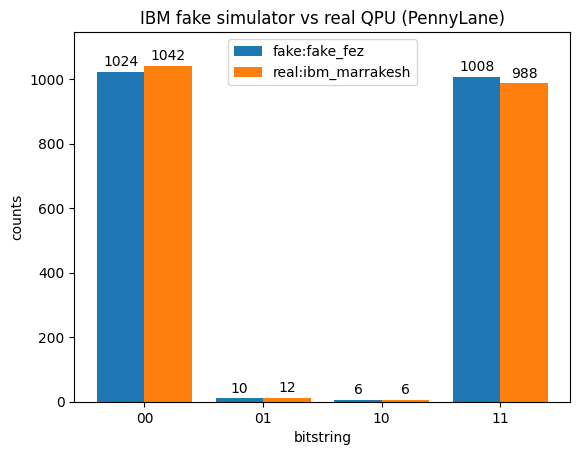

In [ ]:
all_labels = sorted(set(sim_counts) | set(qpu_counts))
sim_vals = [sim_counts.get(k, 0) for k in all_labels]
qpu_vals = [qpu_counts.get(k, 0) for k in all_labels]

x = range(len(all_labels))
w = 0.4
fig, ax = plt.subplots()
bars_sim = ax.bar([i - w/2 for i in x], sim_vals, width=w,
                  label=f"fake:{fake_backend.name}")
bars_qpu = ax.bar([i + w/2 for i in x], qpu_vals, width=w,
                  label=f"real:{real_backend.name}")

ax.bar_label(bars_sim, padding=2)
ax.bar_label(bars_qpu, padding=2)

ax.set_xticks(list(x))
ax.set_xticklabels(all_labels)
ax.set_xlabel("bitstring")
ax.set_ylabel("counts")
ax.set_title("IBM fake simulator vs real QPU (PennyLane)")
ax.legend()
ax.margins(y=0.1)
plt.show()